## Lógica e Programação de Computadores - Fase 2

### Importando as bibliotecas

In [65]:
import os
import csv
import matplotlib.pyplot as plt
import pandas as pd


### Função para Carregar os Dados

In [66]:
def carregar_dados():
    df = pd.read_csv("Base_dados.csv", sep=",")
    df.columns = df.columns.str.strip().str.lower()

    df = df.rename(columns={
        'data': 'Data',
        'precip': 'Precipitacao',
        'maxima': 'TempMax',
        'minima': 'TempMin',
        'um_relativa': 'Umidade',
        'vel_vento': 'Vento'
    })

    df['Data'] = pd.to_datetime(df['Data'], dayfirst=True)
    return df

### Visualização da base de dados

In [67]:
def visualizar_dados(dados, mes_inicio, ano_inicio, mes_fim, ano_fim, tipo_dado):
    print(f"\nVisualizando dados de {mes_inicio}/{ano_inicio} até {mes_fim}/{ano_fim} para {tipo_dado}:\n")
    
    dados_filtrados = dados[
        (dados['Data'].dt.year >= ano_inicio) & (dados['Data'].dt.year <= ano_fim) &
        (dados['Data'].dt.month >= mes_inicio) & (dados['Data'].dt.month <= mes_fim)
    ]

    if tipo_dado == 'precipitacao':
        colunas = ['Data', 'Precipitacao']
    elif tipo_dado == 'temperatura':
        colunas = ['Data', 'TempMax', 'TempMin']
    elif tipo_dado == 'umidade_vento':
        colunas = ['Data', 'Umidade', 'Vento']
    else:
        colunas = ['Data', 'Precipitacao', 'TempMax', 'TempMin', 'Umidade', 'Vento']

    print(dados_filtrados[colunas].to_string(index=False))

### Função para Encontrar o Mês Mais Chuvoso

In [68]:
def mes_mais_chuvoso(dados):
    dados['AnoMes'] = dados['Data'].dt.to_period('M')
    precip_por_mes = dados.groupby('AnoMes')['Precipitacao'].sum().to_dict()

    mes_chuvoso = max(precip_por_mes, key=precip_por_mes.get)
    print(f"\nMês mais chuvoso: {mes_chuvoso} com {precip_por_mes[mes_chuvoso]:.2f} mm de precipitação.")


### Função para Calcular a Média da Temperatura Mínima de um Mês entre 2006 a 2016



In [69]:
def media_temperatura_minima(dados, mes):
    if not (1 <= mes <= 12):
        print("Mês inválido! Informe um número entre 1 e 12.")
        return

    dados_filtrados = dados[
        (dados['Data'].dt.year >= 2006) & (dados['Data'].dt.year <= 2016) &
        (dados['Data'].dt.month == mes)
    ]

    medias = dados_filtrados.groupby(dados_filtrados['Data'].dt.year)['TempMin'].mean()
    dicionario_medias = {f"{mes}/{ano}": round(temp, 2) for ano, temp in medias.items()}

    for chave, valor in dicionario_medias.items():
        print(f"{chave}: {valor}°C")

    return dicionario_medias

### Função para Gerar Gráfico de Temperatura Máxima e Mínima de um Mês


In [70]:
def gerar_grafico_temperatura(dados, mes):
    dicionario = media_temperatura_minima(dados, mes)
    if dicionario:
        anos = list(dicionario.keys())
        medias = list(dicionario.values())

        plt.figure(figsize=(10, 5))
        plt.bar(anos, medias, color='skyblue')
        plt.title(f"Média da Temperatura Mínima em {mes:02d} (2006–2016)")
        plt.xlabel("Ano")
        plt.ylabel("Temperatura Mínima Média (°C)")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # e) Média geral
        media_geral = sum(medias) / len(medias)
        print(f"\nMédia geral da temperatura mínima para o mês {mes}: {media_geral:.2f}°C")


### Função Principal para Rodar o Programa


Visualizando dados de 10/2006 até 10/2016 para todos:

      Data  Precipitacao  TempMax  TempMin  Umidade  Vento
2006-10-01          12.3     24.1     10.4     77.0    1.4
2006-10-02           0.0     22.5     17.5     92.0    0.4
2006-10-03           2.4     23.0     13.3     81.0    2.0
2006-10-04           6.7     27.9     14.8     83.4    4.6
2006-10-05           0.0     29.6     12.6     81.8    0.0
2006-10-06           0.0     23.0      9.0     59.3    2.5
2006-10-07           2.4     27.1     14.6     80.7    1.8
2006-10-08          11.6     27.1      9.4     75.8    1.3
2006-10-09          10.0     29.3      6.8     70.8    1.8
2006-10-10           0.0     30.8     18.7     96.7    2.3
2006-10-11          10.1     35.5      9.7     46.4    1.7
2006-10-12           0.0     22.5     22.7    100.0    3.3
2006-10-13           0.0     33.5     22.5     86.2    1.0
2006-10-14           0.2     25.8     19.9     85.8    3.0
2006-10-15          14.7     18.9     10.2     59.9    1.2


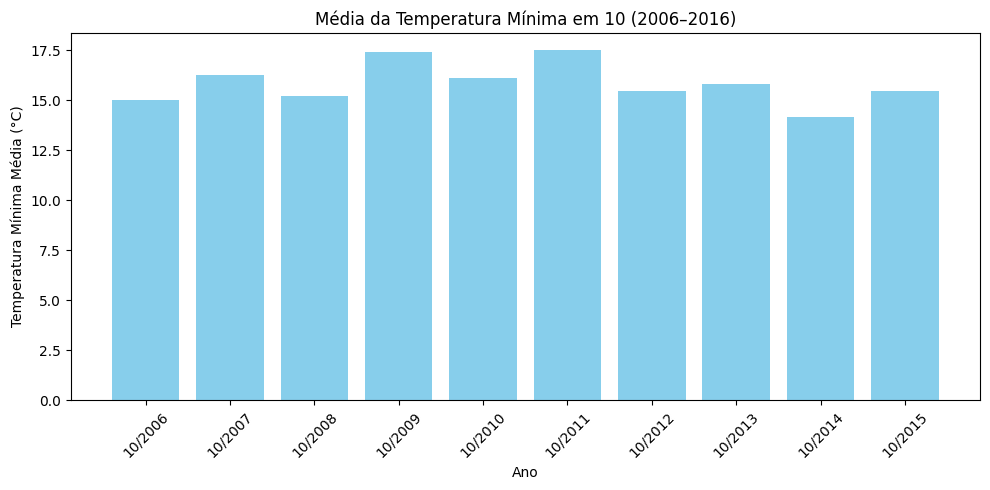


Média geral da temperatura mínima para o mês 10: 15.84°C


In [72]:
def main():
    dados = carregar_dados()

    try:
        mes_inicio = int(input("Digite o mês de início (1-12): "))
        ano_inicio = int(input("Digite o ano de início: "))
        mes_fim = int(input("Digite o mês de fim (1-12): "))
        ano_fim = int(input("Digite o ano de fim: "))
        tipo_dado = input("Digite o tipo de dado (todos, precipitacao, temperatura, umidade_vento): ").lower()

        if tipo_dado not in ['todos', 'precipitacao', 'temperatura', 'umidade_vento']:
            print("Tipo de dado inválido. Exibindo todos os dados.")
            tipo_dado = 'todos'

        visualizar_dados(dados, mes_inicio, ano_inicio, mes_fim, ano_fim, tipo_dado)

        mes_mais_chuvoso(dados)

        mes = int(input("\nDigite o mês (1-12) para análise de temperatura mínima (2006–2016): "))
        gerar_grafico_temperatura(dados, mes)

    except ValueError:
        print("Erro: entrada inválida. Use apenas números onde solicitado.")

# Executar
if __name__ == "__main__":
    main()